# 1. Facebook Artist Page Network (2017)

This notebook includes a comprehensive analysis of a Facebook artist pages network, sourced from the Network Data Repository (Rossi & Ahmed, 2015). The dataset was originally introduced by Rozemberczki et al. (2019) and consists of 819,096 connections between 50,492 nodes. It is represented as an edge list where each row is a mutual like between two artists. This setup provides a structured view of the global music industry on Facebook, potentially revealing community formations, an artist's influence within clusters, and more. The notebook attempts to identify and reveal such structures by applying a series of graph analytics functions from the igraph package in R, accompanied by visual representations of the extracted data.

List of igraph functions used in this notebook:

- `graph_from_data_frame()`
- `vcount()`
- `ecount()`
- `edge_density()`
- `degree()`
- `delete_vertices()`
- `coreness()`
- `eigen_centrality()`
- `page_rank()`
- `assortativity_degree()`
- `cluster_louvain()`
- `hits_scores()`
- `constraint()`
- `edge_connectivity()`
- `bridges()`
- `vertex_connectivity()`
- `mean_distance()`
- `diameter()`
- `betweenness()`
- `similarity()`

# 2. Importing packages

In [2]:
# Importing libarires 

library("igraph")


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




## Reading input files
The dataset is loaded from two files - an edge list and a node list. The node identifiers are aligned with the edge list using the `new_id` column, and 23 edges referencing unlisted nodes are removed to ensure consistency. The graph is then constructed as an undirected network using igraph's `graph_from_data_frame()`, with artist names attached as node labels.

In [3]:
# Reading the graph from the file into an edge list
edges <- read.csv("./data/fb-pages-artist.edges", header = FALSE, col.names = c("from", "to"))
nodes <- read.csv("./data/fb-pages-artist.nodes", header = TRUE)

nodes$new_id <- as.character(nodes$new_id)
edges$from <- as.character(edges$from)
edges$to <- as.character(edges$to)

# Removing edges where either endpoint is missing from nodes
valid_ids <- nodes$new_id
edges <- edges[edges$from %in% valid_ids & edges$to %in% valid_ids,]

# Creating the graph from the edge list
g <- graph_from_data_frame(edges, directed = FALSE, vertices = nodes[, c("new_id", "name")])


## Graph properties

In [4]:
# Creating the graph from the edge list
g <- graph_from_data_frame(edges, directed = FALSE, vertices = nodes[, c("new_id", "name")])

cat("Vertices:", vcount(g), "\n")
cat("Edges:", ecount(g), "\n")
cat("Density:", format(edge_density(g), scientific = FALSE), "\n")
cat("Maximum degree:", max(degree(g)), "\n")
cat("Average degree:", round(mean(degree(g)), 2), "\n")
cat("Minimum degree:", min(degree(g)), "\n")

Vertices: 50492 
Edges: 819096 
Density: 0.0006425816 
Maximum degree: 1468 
Average degree: 32.44 
Minimum degree: 1 


# 3. Graph Simplification
The dataset consists of undirected edges without any duplicates or self-looping connections. In order to properly analyze the overall network, **Sections 4 and 5** apply all the functions on the clean data. For visualization purposes, the dataset is then compressed to around 100 vertices in **Section 6**, which discusses the methods used to achieve this number.

In [47]:
# Original graph statistics
orig_vertices <- igraph::vcount(g)
orig_edges <- igraph::ecount(g)

# Compute degree for each node using igraph
deg <- igraph::degree(g)

# Simplify graph by keeping nodes with degree > 50
g <- igraph::induced_subgraph(g, vids = igraph::V(g)[deg > 50])

# Print comparison statistics
cat("Original Vertices:", orig_vertices, "\n")
cat("Original Edges:", orig_edges, "\n\n")

cat("Vertices (after simplification):", igraph::vcount(g), "\n")
cat("Edges (after simplification):", igraph::ecount(g), "\n")
cat("Density:", igraph::edge_density(g), "\n")
cat("Maximum degree:", max(igraph::degree(g)), "\n")
cat("Average degree:", round(mean(igraph::degree(g)), 2), "\n")
cat("Minimum degree:", min(igraph::degree(g)), "\n")

Original Vertices: 50492 
Original Edges: 819096 

Vertices (after simplification): 8441 
Edges (after simplification): 359376 
Density: 0.01008887 
Maximum degree: 807 
Average degree: 85.15 
Minimum degree: 3 


# 5. Graph Analytics
The goal is to identify important nodes, structural patterns, and communities within the graph using igraph and related graph analysis techniques.

### (a) Central Nodes
**Degree centrality** measures how many connections each node has.
Nodes with high degree values are considered central nodes, because they connect to many other nodes in the network.
In this dataset, such nodes may represent **highly influential or widely connected artist pages** within the Facebook network.

In [5]:
# Compute degree centrality for all nodes
centrality <- degree(g)

# Get top 10 most connected nodes
top_nodes <- sort(centrality, decreasing = TRUE)[1:10]

# Convert to a clean table
top_nodes_df <- data.frame(
  Artist = names(top_nodes),
  Degree = as.numeric(top_nodes)
)

top_nodes_df

Artist,Degree
<chr>,<dbl>
Taylor Swift,1468
Beyoncé,1461
Yuna Alvara,1352
Justin Bieber,1328
The Beatles,1297
Adele,1241
Rihanna,1230
Lady Gaga,1229
Michael Jackson,1211


The output shows the 10 artist pages with the highest number of connections in the network.
These nodes act as ***hubs***, linking many other artists.

## (b) Longest Path
The **diameter** of a graph represents the longest shortest path between any two nodes in the network.
It provides insight into the **maximum distance between artists** within the network.

In [6]:
# Calculate the diameter of the network
diameter_value <- diameter(g)

diameter_value

[1] 11

The diameter indicates ***the largest number of steps required to travel between two artists*** in the network.

In [7]:
# Retrieve the vertices that form the longest path
longest_path <- get_diameter(g)

longest_path

+ 12/50492 vertices, named, from d38deb2:
 [1] Giuseppe Riggio        Patrick Keil           Sandro Brehorst       
 [4] Ois Easy               LINDA HESSE            Die jungen Zillertaler
 [7] Mark Knopfler          Neil Young             Michael Falch         
[10] Lars Lilholt Band      Johnny Madsen          Allan Olsen           

The notation ***+ 12/50492 vertices*** indicates that the path contains **12 nodes out of the total 50492 nodes** in the graph. The path starts with Giuseppe Riggio and ends with Allan Olsen, passing through several intermediate artists such as   Patrick Keil, Sandro Brehorst, Neil Young, Johnny Madsen. Since this path contains 12 nodes, the number of edges between them is 11, which corresponds to the previously computed ***graph diameter of 11***. This means that these two artists are among the most distant nodes in the network

## (c) Largest Clique
A **clique** is a group of nodes where every node is connected to every other node.
Large cliques indicate tightly connected groups of artists who interact frequently.

The result represents ***a fully connected group of artist pages***, where each artist is directly connected to every other artist in the group.

In [8]:
# Identify the largest fully connected groups in the network
largest_cliques_list <- largest_cliques(g)

# Show the size of the largest clique
length(largest_cliques_list[[1]])

# Display the first largest clique
largest_cliques_list[[1]]

[1] 18

+ 18/50492 vertices, named, from d38deb2:
 [1] Tablo                YG FAMILY            BIGBANG             
 [4] Seungri              G-DRAGON             WINNER              
 [7] 2NE1                 Ava Max              SECHSKIES           
[10] iKON                 Koo Hye Sun - 구혜선 EPIK HIGH           
[13] KANG SEUNG YOON      LEE HI (이하이)      BLACKPINK           
[16] PSY                  CL                   AKMU                

The output above shows one of the largest cliques detected in the network, containing ***18 nodes out of 50492***.

### (d) Ego Networks
An **ego network** represents a node and its immediate neighbors.
It helps analyze the **local structure** around a specific artist.

In [9]:
# Select the most connected node
ego_node <- names(top_nodes)[1]
ego_node

[1] "Taylor Swift"

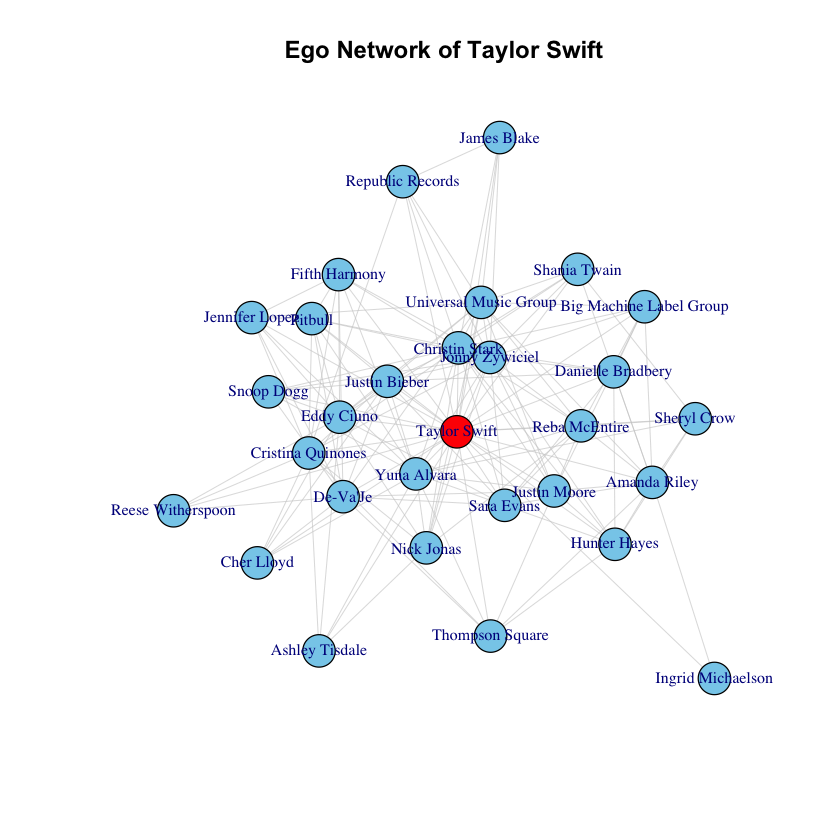

In [21]:

# Get ego nodes (distance = 1)
ego_nodes <- ego(g, order = 1, nodes = ego_node)[[1]]

# Create ego subgraph
ego_graph <- induced_subgraph(g, ego_nodes)

# Compute degree within ego network
deg <- degree(ego_graph)

# Select top 30 nodes by degree
top30 <- names(sort(deg, decreasing = TRUE))[1:30]

# Create smaller ego graph for visualization
ego_graph_small <- induced_subgraph(ego_graph, top30)

# Highlight ego node
V(ego_graph_small)$color <- ifelse(V(ego_graph_small)$name == ego_node, "red", "skyblue")

# Plot ego network
plot(
  ego_graph_small,
  vertex.size = 12,
  vertex.label.cex = 0.8,
  edge.width = 0.5,
  edge.color = "gray80",
  main = paste("Ego Network of", ego_node)
)

The ego network represents a node and all nodes directly connected to it, as we mentioned above. In this case, the ego network of the most connected artist shows the local structure surrounding that artist, illustrating how their page is linked to many other artist pages in the network.

So, our plot represents the ego network of the most connected artist, where the red node indicates **the ego (Taylor Swift)** and the surrounding nodes represent artist's ***most connected neighbors***. To improve visuality, the top 30 nodes are depicted.

## (e) Power Centrality
**Power centrality** measures a node’s influence by considering both **its connections and the importance of its neighbors**.
Nodes connected to other influential nodes will have **higher** power centrality scores.

Power centrality could not be computed on the full graph due to memory limitations. Therefore, it was calculated on a reduced subgraph containing the highest-degree nodes, which preserves the most structurally important part of the network while making the computation feasible.

In [ ]:
# Select top 500 nodes by degree
deg <- degree(g)
top500 <- names(sort(deg, decreasing = TRUE))[1:300]

# Create smaller subgraph
g_power <- induced_subgraph(g, top500)

# Compute power centrality on the reduced graph
power_cent <- power_centrality(g_power)

# Top 10 nodes
top_power_nodes <- sort(power_cent, decreasing = TRUE)[1:10]

# Clean table
top_power_df <- data.frame(
  Artist = names(top_power_nodes),
  PowerCentrality = as.numeric(top_power_nodes)
)

top_power_df

Artist,PowerCentrality
<chr>,<dbl>
Dada Life,2.831598
Joris Voorn,1.740981
Miranda Lambert,1.579397
Solomun (Official),1.539153
Nina Kraviz,1.382091
U2,1.346361
Bob Dylan,1.338034
Paul Van Dyk,1.265048
Erykah Badu,1.032097


Artists such as ***Dada Life, Joris Voorn, and Miranda Lambert*** have the highest power centrality scores, suggesting they are connected to other well-connected artists and play an important role in the structure of the network.

Note that, nodes with high power centrality are ***important connectors in the network***, often linking influential artist communities.

## (f) Community Detection
Communities represent groups of nodes that are **more densely connected to each other than to the rest of the network**.

The **Louvain algorithm** is used to detect communities efficiently in large graphs.

Here we shall stop for a moment and explore the logiv behind this algorithm. As mentioned above, a community is a group of nodes that are **more densely connected to each other than to the rest of the network**. The algorithm identifies these groups by maximizing **modularity**, a measure that evaluates how well the network is divided into communities. Higher modularity values indicate stronger community structure.
The algorithm works iteratively in two main phases. First, each node is initially placed in its own community. Then, the algorithm repeatedly moves nodes to neighboring communities if doing so increases modularity. Once no node movement can further improve modularity, communities are aggregated into single nodes, forming a smaller network. The process is then repeated on this reduced graph until no further modularity improvement is possible. This hierarchical approach makes our **Louvain algorithm** efficient and particularly suitable for large graphs such as the Facebook artist network analyzed in this notebook.

In [12]:
# Detect communities using the Louvain algorithm
communities <- cluster_louvain(g)

# Number of communities
length(communities)

[1] 38

In [14]:
# Community membership of each node
membership_vec <- membership(communities)

# Convert to a clean table
membership_df <- data.frame(
  Artist = names(membership_vec),
  Community = membership_vec
)

head(membership_df, 10)

,Artist,Community
,<chr>,<dbl>
1,Social Club Misfits,1
2,DAMN DICE,2
3,Evokings,3
4,Comatose Music,2
5,Silent Descent,2
6,Jonwayne,4
7,Joey Massa,5
8,Steel Blossoms,6
9,Voxxclub,7


The table shows the community assignment for each artist detected by the algorithm. Artists with the same community number belong to the same cluster of closely connected nodes in the network.

In [15]:
# Community sizes
community_sizes <- sizes(communities)

community_sizes_df <- data.frame(
  Community = seq_along(community_sizes),
  Size = as.numeric(community_sizes)
)

community_sizes_df

Community,Size
<int>,<dbl>
1,2507
2,5278
3,3399
4,3508
5,1094
6,1907
7,1733
8,8735
9,11201


We can observe the size of each ***detected community***, meaning ***how many artists belong to each cluster*** in the network. Larger communities contain more strongly interconnected artists, while smaller communities represent more specialized or niche groups.

This initial visualization appears dense due to the large number of nodes and edges in the graph. This is a common issue in large-scale networks, where many overlapping edges produced a cluttered structure. Thus, we will take first 30 nodes for better visualization purpose:

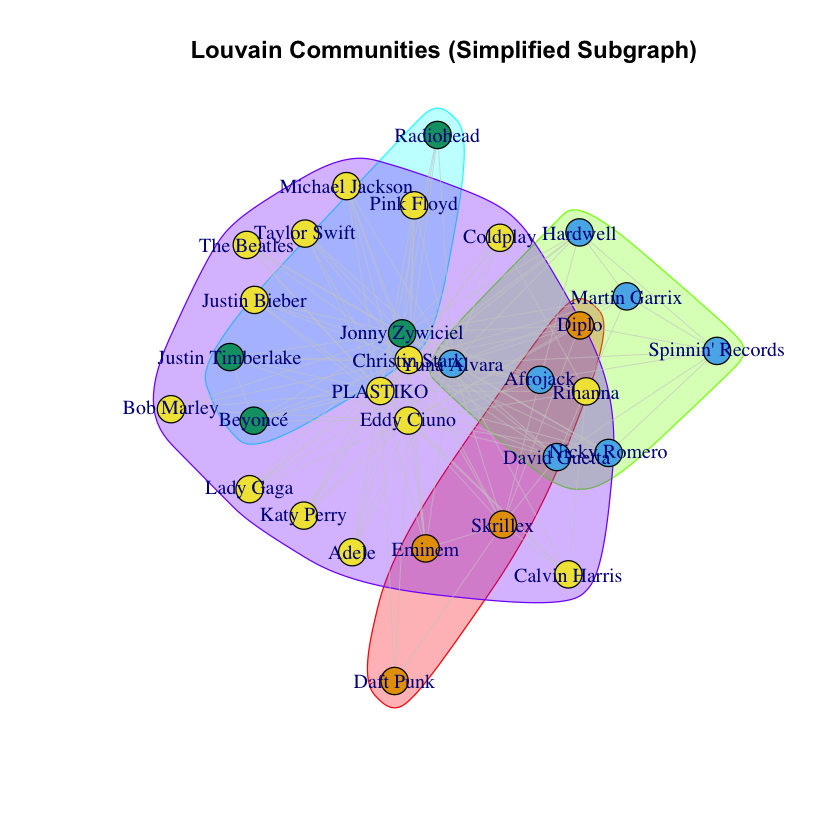

In [31]:
# Take 30 nodes with highest degree for visualization
top_nodes_comm <- names(sort(degree(g), decreasing = TRUE))[1:30]

# Create subgraph
g_vis <- induced_subgraph(g, top_nodes_comm)

# Detect communities
comm_vis <- cluster_louvain(g_vis)

# Plot communities
plot(
  comm_vis,
  g_vis,
  vertex.size = 10,
  vertex.label.cex = 1,
  edge.width = 0.5,
  edge.color = "gray80",
  main = "Louvain Communities (Simplified Subgraph)"
)

The plot visualizes the communities identified by the Louvain algorithm, where each color represents a cluster of closely connected artist pages in the network.

Community detection helps identify ***clusters of artist pages that are closely related***, possibly representing ***shared audiences, genres, or collaborations***.

## Summary for this section
Overall, in this section, our graph analysis aims to highlight the presence of ***highly connected hub nodes, tightly connected groups (cliques), and community structures*** within the Facebook artist network.